<a href="https://colab.research.google.com/github/ishwaripatil618-lang/Google-Skills-APIs-Explorer-Cloud-Storage-GSP421-qwiklabs-arcade-/blob/main/AI_ML_Internship_Project_2_CNN_MNIST0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

TensorFlow version: 2.20.0
Keras version: 3.13.2
GPUs available: 1


In [ ]:
# Step 1: Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("=== MNIST Dataset Info ===")
print(f"Training images : {X_train.shape}")
print(f"Training labels : {y_train.shape}")
print(f"Test images     : {X_test.shape}")
print(f"Test labels     : {y_test.shape}")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")
print(f"Unique classes  : {sorted(set(y_train.tolist()))}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== MNIST Dataset Info ===
Training images : (60000, 28, 28)
Training labels : (60000,)
Test images     : (10000, 28, 28)
Test labels     : (10000,)
Pixel value range: 0 to 255
Unique classes  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


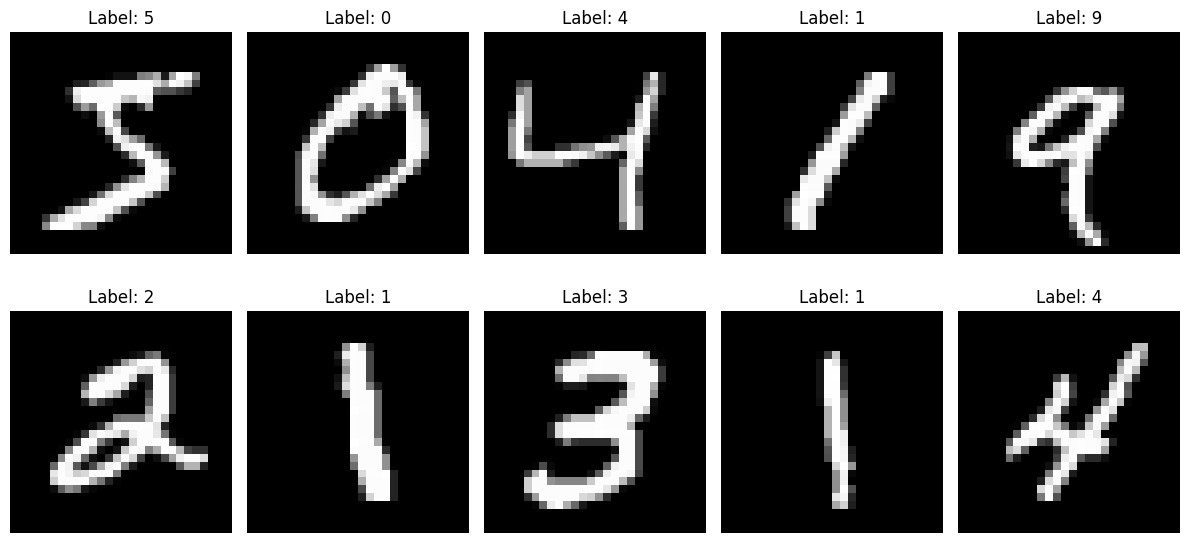

In [ ]:
# Display sample MNIST images

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Preprocess MNIST data

# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape images for CNN: (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("=== After Preprocessing ===")
print("Training images:", X_train.shape)
print("Test images:", X_test.shape)
print("Training labels:", y_train_cat.shape)
print("Test labels:", y_test_cat.shape)
print("Pixel value range:", X_train.min(), "to", X_train.max())

=== After Preprocessing ===
Training images: (60000, 28, 28, 1)
Test images: (10000, 28, 28, 1)
Training labels: (60000, 10)
Test labels: (10000, 10)
Pixel value range: 0.0 to 1.0


In [ ]:
# Step 1: Normalise pixel values from [0,255] to [0.0, 1.0]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Step 2: Reshape — CNNs expect (batch, height, width, channels)
# MNIST is grayscale so channels=1
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print(f'Shape after reshape: {X_train_cnn.shape}')

# Step 3: One-hot encode labels
# label 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe = to_categorical(y_test, num_classes=10)

print(f'Label before one-hot: {y_train[0]}')
print(f'Label after one-hot : {y_train_ohe[0]}')

Shape after reshape: (60000, 28, 28, 1)
Label before one-hot: 5
Label after one-hot : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
def build_cnn(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        # BLOCK 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # BLOCK 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # CLASSIFIER
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_cnn()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,762 (776.41 KB)

 Trainable params: 198,122 (773.91 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")


Model compiled successfully!


In [ ]:
# Step 4: Compile and Train the CNN

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

print('Training CNN on MNIST...')

history = model.fit(
    X_train_cnn,
    y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')
print(f'Epochs trained: {len(history.history["accuracy"])}')

Training CNN on MNIST...
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.8903 - loss: 0.3611 - val_accuracy: 0.1002 - val_loss: 2.9162 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9665 - loss: 0.1114 - val_accuracy: 0.4512 - val_loss: 2.5076 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9739 - loss: 0.0846 - val_accuracy: 0.8338 - val_loss: 0.4766 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9787 - loss: 0.0701 - val_accuracy: 0.7770 - val_loss: 0.7879 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9825 - loss: 0.0580 - val_accuracy: 0.2571 - val_loss: 7.8833 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9623 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accurac

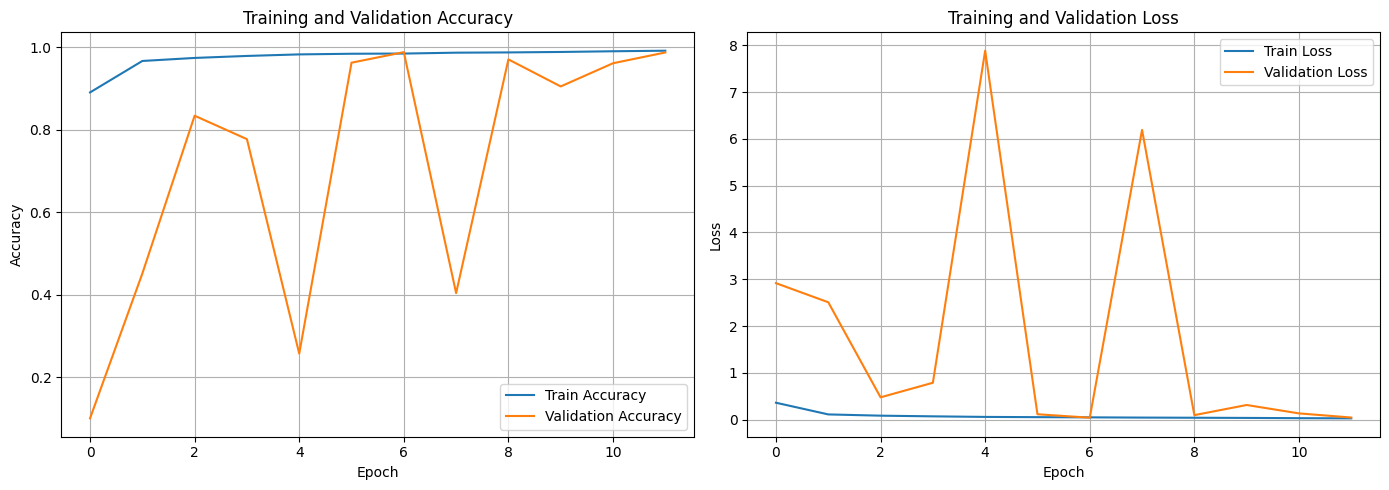

In [ ]:
# Step 5: Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('mnist_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


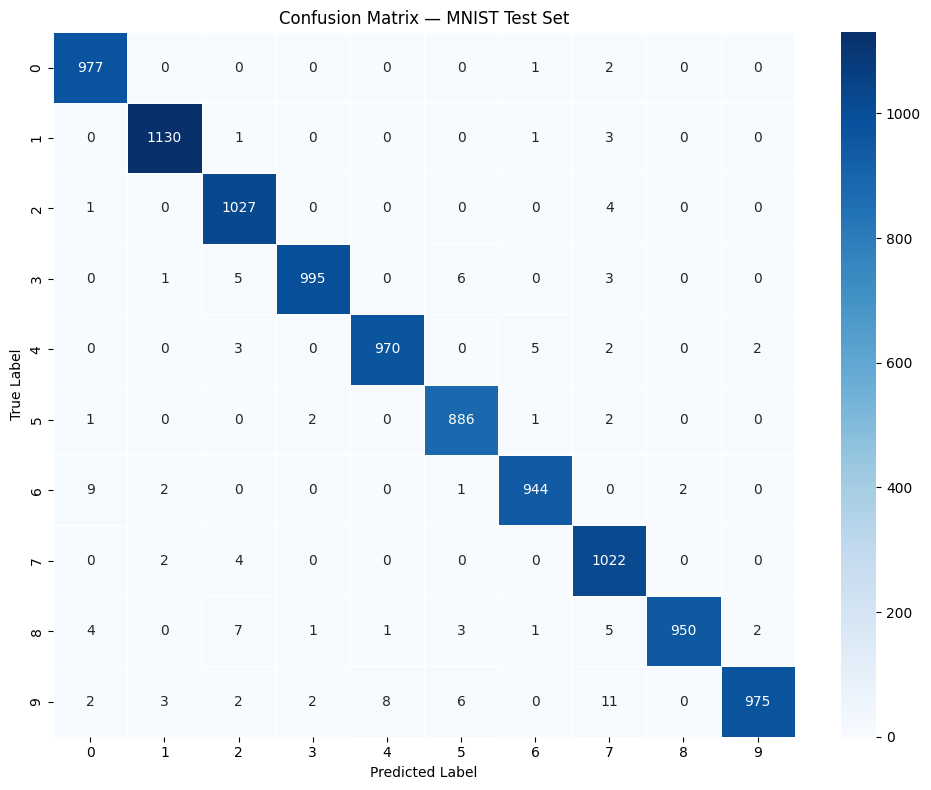

In [ ]:
# Get predictions
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5
)

plt.title('Confusion Matrix — MNIST Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('mnist_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Total misclassified: 124 / 10000
Error rate: 1.24%


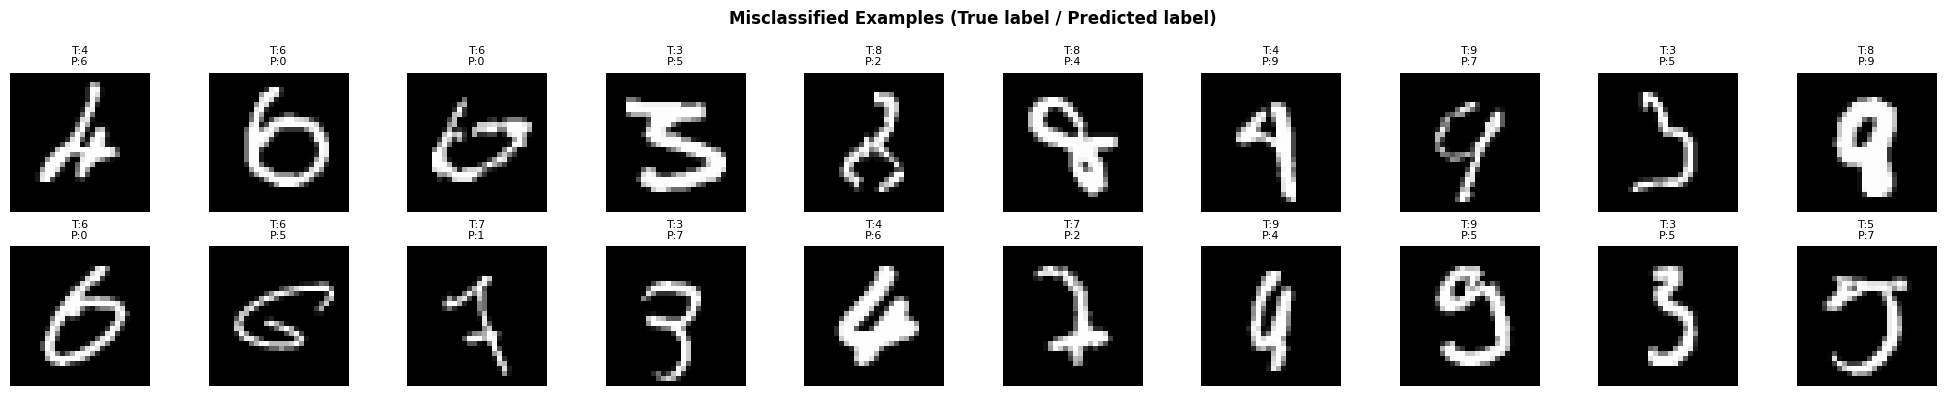

In [ ]:
# Show misclassified examples

wrong_idx = np.where(y_pred != y_true)[0]

print(f"\nTotal misclassified: {len(wrong_idx)} / {len(y_true)}")
print(f"Error rate: {len(wrong_idx) / len(y_true) * 100:.2f}%")

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i, idx in enumerate(wrong_idx[:20]):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f'T:{y_true[idx]}\nP:{y_pred[idx]}', fontsize=8)
    ax.axis('off')

plt.suptitle(
    'Misclassified Examples (True label / Predicted label)',
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('mnist_errors.png', dpi=150, bbox_inches='tight')
plt.show()